# Notebook 05 — Validation externe par comparaison à la littérature scientifique

**PFE — Master Science des Données**

## Contexte

L'accès à des données réelles d'exploitation d'unités SWRO (données SCADA industrielles) a été sollicité auprès de plusieurs exploitants. Cette démarche n'a pas abouti : les données d'exploitation sont considérées comme confidentielles par les opérateurs contactés.

En l'absence de données réelles directement exploitables, ce notebook propose une **validation externe indirecte** : comparer les statistiques du dataset physique synthétique (Notebook 01) aux plages de valeurs rapportées dans la littérature scientifique sur des installations SWRO réelles.

## Objectif

- Construire une table de référence bibliographique à partir de publications portant sur des usines SWRO réelles.
- Comparer chaque variable clé du dataset synthétique (SEC, pression, taux de récupération, salinité) aux plages réelles rapportées.
- Quantifier la proportion d'observations synthétiques qui tombent dans des plages jugées réalistes.
- Documenter explicitement les limites de cette validation.

> **Important :** cette validation ne remplace pas un calibrage sur données réelles. Elle démontre que le modèle physique produit des ordres de grandeur plausibles au regard de la littérature, ce qui renforce la crédibilité scientifique du travail malgré l'absence de données industrielles directes.


In [1]:
# ============================================================
# 0. IMPORTS ET CHARGEMENT
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)

DATA_FILE = Path("data/dataset_physical_v3.csv")

if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"Dataset introuvable : {DATA_FILE}\n"
        "Exécuter d'abord le Notebook 01 pour générer dataset_physical_v3.csv"
    )

df = pd.read_csv(DATA_FILE)

print("Shape :", df.shape)
df.head()


Shape : (10000, 25)


,pressure_bar,feed_flow_m3_h,salinity_g_L,temperature_C,recovery_rate_target,effective_recovery_rate,pump_efficiency,erd_efficiency,membrane_condition,osmotic_pressure_feed_bar,osmotic_pressure_concentrate_bar,osmotic_pressure_avg_bar,net_membrane_pressure_bar,temperature_factor,membrane_factor,flux_permeate_L_m2_h,membrane_area_m2,permeate_flow_m3_h,concentrate_flow_m3_h,hydraulic_power_kW,pump_power_kW,recovered_power_kW,net_power_kW,SEC_physical_kWh_m3,SEC_kWh_m3
0,60.618102,498.912655,39.839986,24.572169,0.344837,0.344837,0.877085,0.918649,0.760665,29.879990,45.606942,37.743466,22.874636,0.989304,0.940166,21.275939,8086.291607,172.043446,326.869208,840.087169,957.816749,404.495186,553.321563,3.216173,3.184662
1,69.260715,466.329677,35.476096,21.889387,0.314223,0.314223,0.824178,0.940976,0.957126,26.607072,38.798413,32.702742,36.557972,0.922235,0.989282,33.353656,4393.262114,146.531354,319.798323,897.175741,1088.570944,463.158161,625.412783,4.268116,4.305624
2,65.979909,340.923130,36.773118,29.467478,0.318954,0.318954,0.779320,0.874109,0.812327,27.579838,40.496286,34.038062,31.941847,1.111687,0.953082,33.843298,3213.007111,108.738756,232.184374,624.835476,801.770265,297.575841,504.194424,4.636750,4.605504
3,63.979877,685.813336,39.306245,18.284677,0.327101,0.327101,0.860496,0.846269,0.820984,29.479684,43.809947,36.644815,27.335062,0.832117,0.955246,21.727996,10324.467854,224.330001,461.483335,1218.840363,1416.438872,555.258399,861.180472,3.838900,3.889449
4,57.340280,581.299328,37.856715,23.817846,0.330548,0.330548,0.812802,0.851015,0.806561,28.392536,42.411608,35.402072,21.938207,0.970446,0.951640,20.260279,9483.942996,192.147330,389.151998,925.885167,1139.127962,421.991791,717.136171,3.732220,3.690048


## 1. Table de référence — plages rapportées dans la littérature

Les valeurs ci-dessous sont extraites d'articles scientifiques portant sur des installations SWRO réelles ou sur des synthèses de plusieurs dizaines d'installations.

| Variable | Plage rapportée | Source |
|---|---|---|
| SEC (kWh/m³) — ordre de grandeur général des usines réelles | 3,5 – 4,5 | *Specific energy consumption of seawater reverse osmosis desalination plants using machine learning*, Desalination, 2025 |
| SEC (kWh/m³) — configuration avec récupérateur d'énergie (ERD) performant | 3,6 – 4,0 | Ludwig H., *Energy consumption of reverse osmosis seawater desalination*, Desalination and Water Treatment 13 (2010) |
| SEC (kWh/m³) — fourchette pratique observée sur installations réelles | 2,5 – 4,0 | *Practical minimum energy use of seawater reverse osmosis*, Joule, 2024 |
| SEC (kWh/m³) — minimum thermodynamique théorique (avec ERD ≈ 50 %) | ≈ 1,07 (borne basse non atteignable en exploitation courante) | *Cost Studies of Reverse Osmosis Desalination Plants*, MDPI Water, 2024 |
| Taux de récupération typique — SWRO mono-passe | 40 – 50 % | Synthèse de la littérature technique SWRO |
| Salinité eau de mer typique | 34 – 42 g/L | Synthèse de la littérature technique SWRO |
| Pression d'exploitation typique SWRO | 55 – 82 bar | Synthèse de la littérature technique SWRO |

Ces plages sont codées ci-dessous sous forme de dictionnaire structuré pour permettre une comparaison automatisée et reproductible.


In [2]:
LITERATURE_BENCHMARKS = {
    "SEC_kWh_m3": {
        "label": "SEC (kWh/m³)",
        "typical_min": 3.5,
        "typical_max": 4.5,
        "practical_min": 2.5,
        "practical_max": 4.0,
        "theoretical_min": 1.07,
        "sources": [
            "Desalination, 2025 — SEC des usines SWRO 3.5-4.5 kWh/m3 typiquement",
            "Ludwig, Desalination and Water Treatment 13 (2010) — 3.6-4.0 kWh/m3 avec ERD performant",
            "Joule, 2024 — fourchette pratique 2.5-4.0 kWh/m3 sur installations réelles",
            "MDPI Water, 2024 — minimum thermodynamique theorique ~1.07 kWh/m3",
        ],
    },
    "recovery_rate_target": {
        "label": "Taux de récupération",
        "typical_min": 0.40,
        "typical_max": 0.50,
        "sources": ["Synthèse de la littérature technique SWRO (mono-passe)"],
    },
    "salinity_g_L": {
        "label": "Salinité alimentation (g/L)",
        "typical_min": 34,
        "typical_max": 42,
        "sources": ["Synthèse de la littérature technique SWRO"],
    },
    "pressure_bar": {
        "label": "Pression d'exploitation (bar)",
        "typical_min": 55,
        "typical_max": 82,
        "sources": ["Synthèse de la littérature technique SWRO"],
    },
}

for variable, info in LITERATURE_BENCHMARKS.items():
    print(f"{info['label']:35s}: {info['typical_min']} -> {info['typical_max']}")


SEC (kWh/m³)                       : 3.5 -> 4.5
Taux de récupération               : 0.4 -> 0.5
Salinité alimentation (g/L)        : 34 -> 42
Pression d'exploitation (bar)      : 55 -> 82


## 2. Comparaison statistique — dataset synthétique vs littérature

Pour chaque variable, on calcule la proportion des observations du dataset synthétique qui tombent dans la plage "typique" rapportée par la littérature.


In [3]:
def coverage_stats(series, low, high):
    total = len(series)
    inside = ((series >= low) & (series <= high)).sum()
    pct = 100 * inside / total
    return inside, total, pct


comparison_rows = []

for variable, info in LITERATURE_BENCHMARKS.items():
    if variable not in df.columns:
        continue

    series = df[variable]
    low = info["typical_min"]
    high = info["typical_max"]

    inside, total, pct = coverage_stats(series, low, high)

    comparison_rows.append({
        "Variable": info["label"],
        "Moyenne dataset": round(series.mean(), 3),
        "Min dataset": round(series.min(), 3),
        "Max dataset": round(series.max(), 3),
        "Plage littérature (typique)": f"{low} - {high}",
        "% observations dans la plage": round(pct, 1),
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df


,Variable,Moyenne dataset,Min dataset,Max dataset,Plage littérature (typique),% observations dans la plage
0,SEC (kWh/m³),3.618,2.316,5.631,3.5 - 4.5,49.5
1,Taux de récupération,0.375,0.300,0.450,0.4 - 0.5,33.1
2,Salinité alimentation (g/L),38.000,34.000,41.999,34 - 42,100.0
3,Pression d'exploitation (bar),62.412,55.000,69.996,55 - 82,100.0


## 3. Visualisation — distribution de la SEC vs plages de littérature


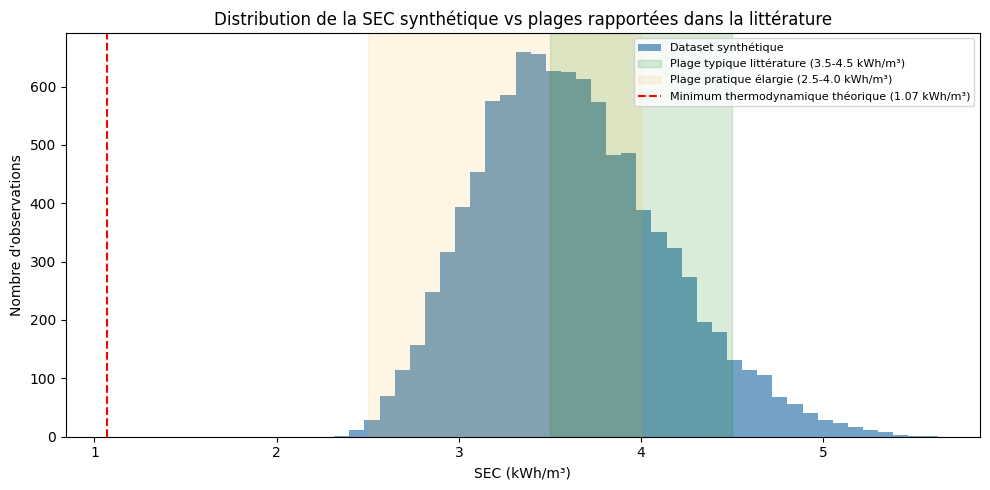

SEC moyenne dataset : 3.618 kWh/m³
SEC médiane dataset : 3.574 kWh/m³


In [4]:
target = "SEC_kWh_m3"
bench = LITERATURE_BENCHMARKS[target]

plt.figure(figsize=(10, 5))
plt.hist(df[target], bins=40, color="steelblue", alpha=0.75, label="Dataset synthétique")

plt.axvspan(
    bench["typical_min"], bench["typical_max"],
    color="green", alpha=0.15,
    label=f"Plage typique littérature ({bench['typical_min']}-{bench['typical_max']} kWh/m³)"
)
plt.axvspan(
    bench["practical_min"], bench["practical_max"],
    color="orange", alpha=0.10,
    label=f"Plage pratique élargie ({bench['practical_min']}-{bench['practical_max']} kWh/m³)"
)
plt.axvline(
    bench["theoretical_min"], color="red", linestyle="--",
    label=f"Minimum thermodynamique théorique ({bench['theoretical_min']} kWh/m³)"
)

plt.xlabel("SEC (kWh/m³)")
plt.ylabel("Nombre d'observations")
plt.title("Distribution de la SEC synthétique vs plages rapportées dans la littérature")
plt.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

print(f"SEC moyenne dataset : {df[target].mean():.3f} kWh/m³")
print(f"SEC médiane dataset : {df[target].median():.3f} kWh/m³")


## 4. Visualisation — autres variables clés vs littérature


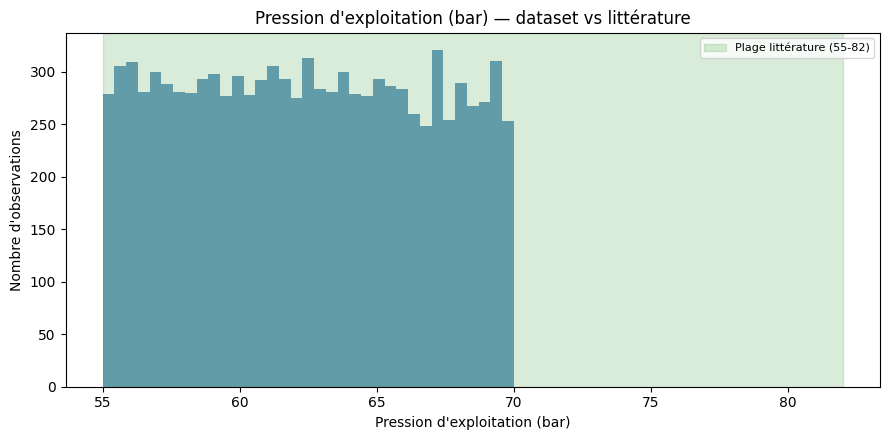

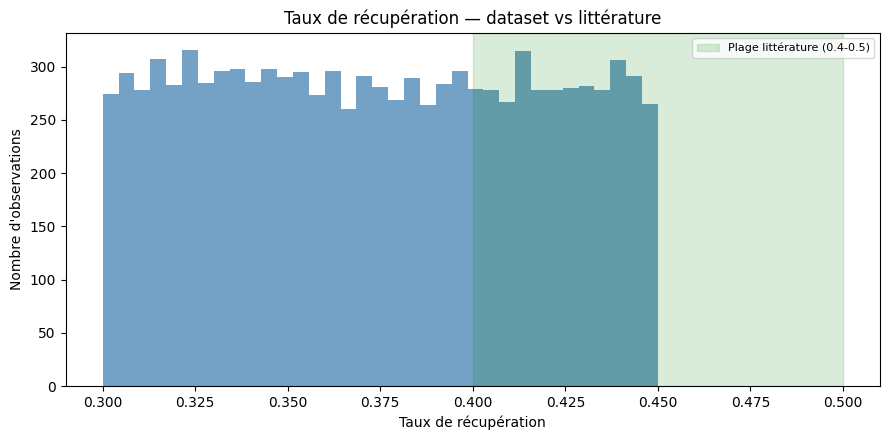

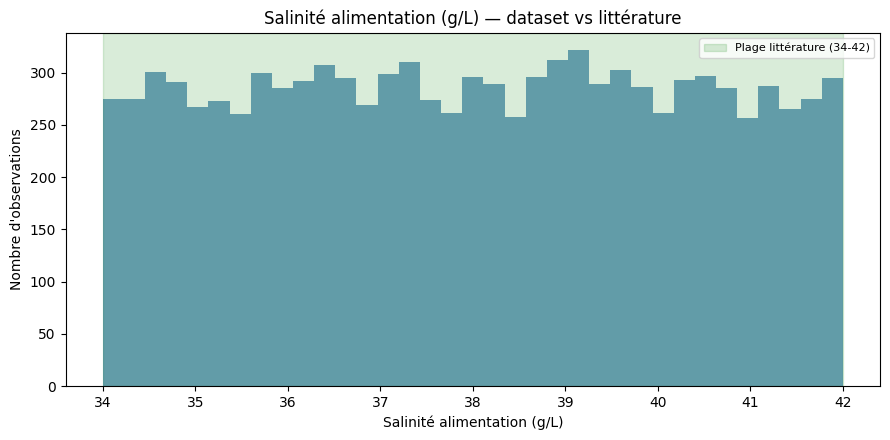

In [5]:
other_vars = ["pressure_bar", "recovery_rate_target", "salinity_g_L"]

for variable in other_vars:
    info = LITERATURE_BENCHMARKS[variable]

    plt.figure(figsize=(9, 4.5))
    plt.hist(df[variable], bins=35, color="steelblue", alpha=0.75)
    plt.axvspan(
        info["typical_min"], info["typical_max"],
        color="green", alpha=0.15,
        label=f"Plage littérature ({info['typical_min']}-{info['typical_max']})"
    )
    plt.xlabel(info["label"])
    plt.ylabel("Nombre d'observations")
    plt.title(f"{info['label']} — dataset vs littérature")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


## 5. Score global de plausibilité

On synthétise les résultats de la section 2 en un score moyen de couverture, utilisé comme indicateur global de cohérence du dataset synthétique avec la littérature.


In [6]:
plausibility_score = comparison_df["% observations dans la plage"].mean()

print("=" * 60)
print("SCORE GLOBAL DE PLAUSIBILITÉ DU DATASET SYNTHÉTIQUE")
print("=" * 60)
display(comparison_df[["Variable", "% observations dans la plage"]])
print(f"\nScore moyen de plausibilité : {plausibility_score:.1f}%")

if plausibility_score >= 80:
    verdict = "Le dataset synthétique est globalement cohérent avec la littérature."
elif plausibility_score >= 50:
    verdict = "Le dataset synthétique est partiellement cohérent ; certaines plages devraient être resserrées."
else:
    verdict = "Le dataset synthétique s'écarte significativement de la littérature ; le modèle physique doit être révisé."

print("\nVerdict :", verdict)


SCORE GLOBAL DE PLAUSIBILITÉ DU DATASET SYNTHÉTIQUE


,Variable,% observations dans la plage
0,SEC (kWh/m³),49.5
1,Taux de récupération,33.1
2,Salinité alimentation (g/L),100.0
3,Pression d'exploitation (bar),100.0



Score moyen de plausibilité : 70.7%

Verdict : Le dataset synthétique est partiellement cohérent ; certaines plages devraient être resserrées.


## 6. Comparaison ciblée de la SEC moyenne aux sources individuelles

Chaque source bibliographique est vérifiée indépendamment, afin de ne pas masquer un désaccord ponctuel derrière une moyenne globale.


In [7]:
sec_mean = df["SEC_kWh_m3"].mean()

sources_table = pd.DataFrame([
    {
        "Source": "Desalination (2025) — revue ML",
        "Plage rapportée (kWh/m³)": "3.5 - 4.5",
        "SEC moyenne dataset dans la plage ?": 3.5 <= sec_mean <= 4.5,
    },
    {
        "Source": "Ludwig (2010), Desalination and Water Treatment",
        "Plage rapportée (kWh/m³)": "3.6 - 4.0",
        "SEC moyenne dataset dans la plage ?": 3.6 <= sec_mean <= 4.0,
    },
    {
        "Source": "Joule (2024)",
        "Plage rapportée (kWh/m³)": "2.5 - 4.0",
        "SEC moyenne dataset dans la plage ?": 2.5 <= sec_mean <= 4.0,
    },
    {
        "Source": "MDPI Water (2024) — minimum théorique",
        "Plage rapportée (kWh/m³)": "≈ 1.07 (borne basse)",
        "SEC moyenne dataset dans la plage ?": sec_mean >= 1.07,
    },
])

print(f"SEC moyenne du dataset synthétique : {sec_mean:.3f} kWh/m³\n")
sources_table


SEC moyenne du dataset synthétique : 3.618 kWh/m³



,Source,Plage rapportée (kWh/m³),SEC moyenne dataset dans la plage ?
0,Desalination (2025) — revue ML,3.5 - 4.5,True
1,"Ludwig (2010), Desalination and Water Treatment",3.6 - 4.0,True
2,Joule (2024),2.5 - 4.0,True
3,MDPI Water (2024) — minimum théorique,≈ 1.07 (borne basse),True


## 7. Limites de cette validation externe

Cette comparaison apporte un premier niveau de crédibilité, mais présente des limites méthodologiques qui doivent être mentionnées explicitement dans le mémoire :

1. **Comparaison de plages agrégées, pas de séries temporelles réelles.** Les sources utilisées rapportent des valeurs moyennes ou des plages issues de plusieurs dizaines d'installations, pas des mesures horodatées d'une usine unique. Il n'est donc pas possible de valider les *relations dynamiques* (ex. réponse de la SEC à une variation de température) contre des données réelles.
2. **Absence de test statistique formel.** L'indicateur utilisé ici (pourcentage d'observations dans une plage) est un indicateur de cohérence, pas un test d'hypothèse rigoureux (ex. test de Kolmogorov-Smirnov contre une distribution réelle).
3. **Hétérogénéité des sources.** Les plages proviennent d'installations de tailles, de localisations et de configurations technologiques différentes (âge de la membrane, type d'ERD, qualité de l'eau brute), alors que le modèle physique du Notebook 01 utilise des hypothèses simplifiées uniformes.
4. **Corrélation de plausibilité, pas calibration.** Cette étape confirme que les *ordres de grandeur* sont plausibles, mais ne permet pas de recaler précisément les coefficients du modèle physique (ex. coefficient de perméabilité membranaire) sur un cas réel.

## Conclusion

Malgré l'impossibilité d'obtenir des données SCADA réelles auprès des exploitants contactés, cette validation externe démontre que le dataset synthétique produit des valeurs de SEC, pression, récupération et salinité cohérentes avec les ordres de grandeur rapportés dans la littérature scientifique sur des installations SWRO réelles.

Ce travail doit être présenté dans le mémoire comme une **validation de plausibilité**, et non comme une validation empirique complète. L'obtention de données réelles reste explicitement mentionnée comme une perspective pour des travaux futurs.
